# micrograd 课程实验

## 手动实现反向传播

In [26]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

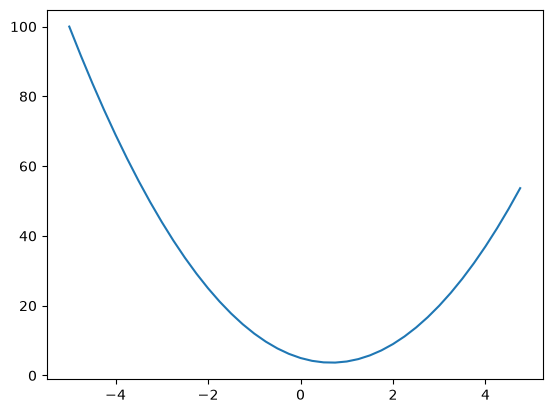

In [12]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [ ]:
h = 0.00000001
x = 2/3
(f(x+h) - f(x)) / h

0.0

In [37]:
h = 0.00000001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c
print(f'd1:{d1}\nd2:{d2}\nslop:{(d2-d1) / h}')

d1:4.0
d2:4.000000010000001
slop:1.000000082740371


In [ ]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda : None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(label={self.label}, data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        res = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += res.grad
            other.grad += res.grad
        res._backward = _backward

        return res

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        res = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * res.grad
            other.grad += self.data * res.grad
        res._backward = _backward

        return res

    def __rmul__(self, other):
        return self * other

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return other + (-self)

    def __neg__(self):
        return self * -1

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        res = Value(self.data**other, (self, ), f'**{other}')
        
        def _backward():
            self.grad += other * self.data**(other-1) * res.grad
        res._backward = _backward

        return res

    def tanh(self):
        res = Value((math.exp(2 * self.data) - 1) / (math.exp(2 * self.data) + 1), (self, ), 'tanh')
        
        def _backward():
            self.grad += (1 - res.data**2) * res.grad
        res._backward = _backward
        
        return res

    def backward(self):
        # use topological sort to automatic caculate gradient of every node
        # the beginning of backpropagation
        self.grad = 1.0
        topo = []
        visited = set()
        # reverse topological sort: the first input node will be the first element in topo list
        def sort_(v):
            visited.add(v)
            for child in v._prev:
                if child not in visited:
                    sort_(child)
            topo.append(v)
            # print(topo[-1])
        sort_(self)

        # reverse the result to use the correct order to backpropagate (start with the last output)
        for node in topo[::-1]:
            node._backward()

In [81]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
print(L, L.grad, L._prev, L._op)

Value(data=-8.0) 0.0 {Value(data=-2.0), Value(data=4.0)} *


In [12]:
# 这里是karpathy用来绘制表达式的DAG的代码，graphviz在真正ml/dl行业并不常用，所以这里复制过来直接使用，我只改了节点字符串的格式

from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = f"{{ {n.label} | data {n.data:.4f} | {n.grad:.4f} }}", shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

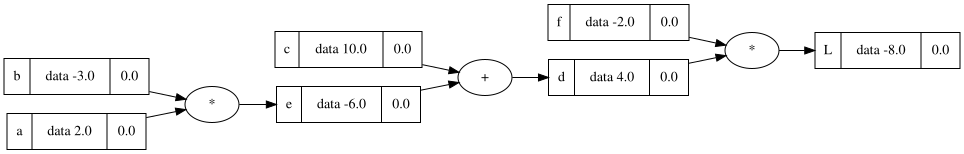

In [83]:
draw_dot(L)

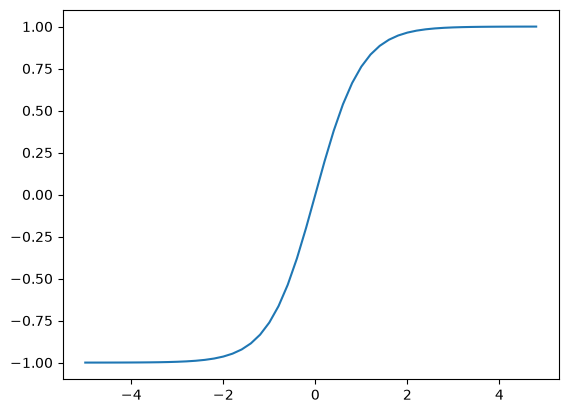

In [7]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)))

In [89]:
# neuron init
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

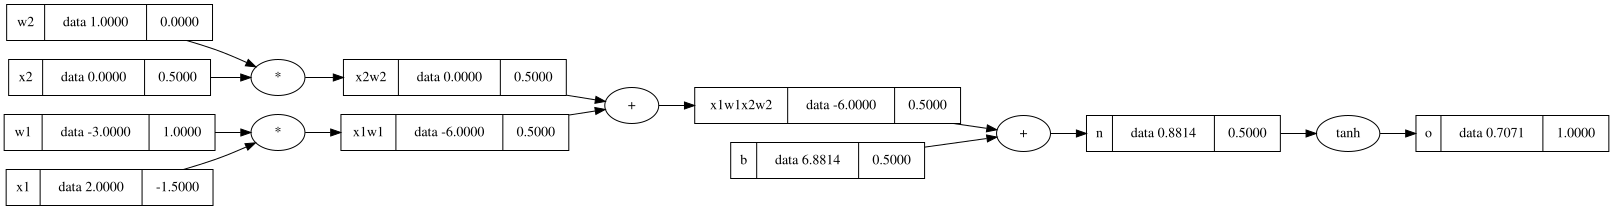

In [92]:
draw_dot(o)

In [ ]:
o.backward()

Value(label=o, data=0.7071067811865476)
Value(label=n, data=0.8813735870195432)
Value(label=b, data=6.881373587019543)
Value(label=x1w1x2w2, data=-6.0)
Value(label=x1w1, data=-6.0)
Value(label=x1, data=2.0)
Value(label=w1, data=-3.0)
Value(label=x2w2, data=0.0)
Value(label=x2, data=0.0)
Value(label=w2, data=1.0)


In [43]:
o.grad = 1.0
n.grad = math.exp(2*n.data) * 4 / pow(math.exp(2*n.data) + 1, 2) # do / dn = 1 - o.data**2
b.grad = 0.5
x1w1x2w2.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
x1.grad = -1.5
w1.grad = 1
x2.grad = 0.5
w2.grad = 0

In [42]:
def lol():
    h = 0.000001

    x1 = Value(2.0, label='x1')
    x2 = Value(0.0, label='x2')
    
    w1 = Value(-3.0, label='w1')
    w2 = Value(1.0, label='w2')
    
    b = Value(6.8813735870195432, label='b')

    x1w1 = x1 * w1; x1w1.label = 'x1w1'
    x2w2 = x2 * w2; x2w2.label = 'x2w2'
    x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

    n = x1w1x2w2 + b; n.label = 'n'

    o = n.tanh(); o.label = 'o'
    
    o1 = o

    x1 = Value(2.0, label='x1')
    x2 = Value(0.0, label='x2')
    
    w1 = Value(-3.0, label='w1')
    w2 = Value(1.0, label='w2')
    
    b = Value(6.8813735870195432, label='b')

    x1w1 = x1 * w1; x1w1.label = 'x1w1'
    x2w2 = x2 * w2; x2w2.label = 'x2w2'
    x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

    n = x1w1x2w2 + b; n.label = 'n'
    n.data += h

    o = n.tanh(); o.label = 'o'
    o2 = o

    n.grad = (o2.data - o1.data) / h
    print(n.grad)
lol()


0.49999964646385564


## PyTorch 反向传播和自动微分

In [93]:
import torch

In [104]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o)
print(o.data)
print(o.data.item())

o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)
tensor([0.7071], dtype=torch.float64)
0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


## 构建一个小神经网络（两层感知机，用自造的`Value`）

In [129]:
import random

# This is a simple binary classifier nn

# __init__ of every class means initating weights and bias randomly
#          In real enginering, the parameters in __init__ always use `nin` for input and `nout` for output.
#          This is a experiment for study, so the name of parameters will be complicate but more readable.
# __call__ of every class means evaluating corresponding instance to forward propagating the output
# Wrapping it up, __init__ is for initating the skeleton of nn, and __call__ is for feeding inputs and forward propagating

class Neuron:
    def __init__(self, neuron_in_num: int):
        self.weights = [Value(random.uniform(-1, 1)) for _ in range(neuron_in_num)]
        self.bias = Value(random.uniform(-1, 1))

    def __call__(self, inputs_from_prev_layer_neurons: list):
        # w*x + b
        out = sum((w*x for w, x in zip(self.weights, inputs_from_prev_layer_neurons)), start=self.bias)
        squash = out.tanh()
        return squash

    def parameters(self):
        return self.weights + [self.bias]

class Layer:
    def __init__(self, neuron_in_num: int, neuron_out_num: int):
        self.neurons = [Neuron(neuron_in_num) for _ in range(neuron_out_num)]
    
    def __call__(self, inputs_from_prev_layer: list):
        out = [neuron(inputs_from_prev_layer) for neuron in self.neurons]
        return out if len(out) != 1 else out[0]

    def parameters(self):
        return [n for neuron in self.neurons for n in neuron.parameters()]

class MLP:
    def __init__(self, layers_num: list):
        self.layers = [Layer(layers_num[i], layers_num[i+1]) for i in range(len(layers_num) - 1)]
    
    def __call__(self, inputs_from_outer):
        # inputs_from_outer: 
        # the first element is the number of inputs and the last element is the nubmer of outputs (usually use 1)
        out = inputs_from_outer
        for layer in self.layers:
            out = layer(out)
        return out

    def parameters(self):
        return [l for layer in self.layers for l in layer.parameters()]

In [238]:
x = [Value(2.0, label='x1'), Value(3.0, label='x2'), Value(-1.0, label='x3')]
nn = MLP([3, 4, 4, 1])    # 3 inputs ; 1 output; 2 mediate layers (each has 4 neurons)
# Actually when building nn, 3 layers are built in nn. They are two mediate layers and one output layer
# The input layer is x logically.

nn(x)
# draw_dot(nn(x))

Value(label=, data=0.41488656678561825)

In [171]:
# inputs
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
# desired targets/outputs
ys = [1.0, -1.0, -1.0, 1.0]

# predicted outputs
ypreds = [nn(x) for x in xs]
ypreds

[Value(label=, data=0.15329689596486304),
 Value(label=, data=-0.04394401652520975),
 Value(label=, data=0.1626439024462631),
 Value(label=, data=0.12031642840848202)]

In [172]:
# loss
# the mean suqared error loss
err = [(y - ypred)**2 for y, ypred in zip(ys, ypreds)]
loss = sum(err)
print(err)
print(loss)

[Value(label=, data=0.7169061463827359), Value(label=, data=0.9140430435379484), Value(label=, data=1.3517408438954759), Value(label=, data=0.7738431861280094)]
Value(label=, data=3.7565332199441697)


In [173]:
loss.backward()

In [134]:
print(nn.layers[0].neurons[0].weights[0].grad)
print(nn.layers[0].neurons[0].weights[0].data)

0.00864844943104556
-0.7240889833956294


In [ ]:
draw_dot(loss)

In [135]:
print(nn.parameters())
print(len(nn.parameters()))

[Value(label=, data=-0.7240889833956294), Value(label=, data=-0.2552336869947107), Value(label=, data=0.6489014191252527), Value(label=, data=-0.33416571497236247), Value(label=, data=0.36980549159768916), Value(label=, data=-0.08744882636371987), Value(label=, data=-0.1721960927156565), Value(label=, data=-0.5326400171543235), Value(label=, data=0.7947052481646935), Value(label=, data=-0.24560965090721965), Value(label=, data=0.060500064857510694), Value(label=, data=0.858840423153751), Value(label=, data=-0.3249598285734696), Value(label=, data=-0.4454905462824186), Value(label=, data=-0.46122112681761784), Value(label=, data=0.9586004570790854), Value(label=, data=0.09265358877063212), Value(label=, data=0.32119628232993924), Value(label=, data=0.9748829571301767), Value(label=, data=-0.9816189209909543), Value(label=, data=0.7052405594506248), Value(label=, data=-0.4257156147039345), Value(label=, data=0.46440426054542283), Value(label=, data=0.7866861571619042), Value(label=, data

In [ ]:
# From this cell and two cells right below, they build a loop to nudge every weight in nn for decrease the loss.
# The fastest way that loss goes down is following the reverse derection of gradients of every neuron.
# This is the famous way: gradient descent

# 3. Update the weights and biases
# So, the grad should multiply a tiny negative number (It's called learning rate)
# If the learning rate, or it can be called step, is setten too big, the ypred could overstep (over the optimal solution)
# It may be caused loss increasing evenly!
# We can also use learning rate decay.
# It looks like `learning_rate = 1.0 - 0.9*k/100`
# In the beginning, it will high. And with the turns of training increasing, the learning rate should goes down to ensure the thing that talked above will not happen
# Actually, it means set learning rate dynamically
for p in nn.parameters():
    p.data += -0.01 * p.grad

In [211]:
# 1. Forward pass
# Recaculate the predictions and loss
ypreds = [nn(x) for x in xs]
err = [(y - ypred)**2 for y, ypred in zip(ys, ypreds)]
loss = sum(err)

# The loss has decreased!
# And the results, ypred, are getting closer and closer to the y (ys)
print(ypreds)
print(loss)

[Value(label=, data=0.9341197098756996), Value(label=, data=-0.9466400826422999), Value(label=, data=-0.9475281852154803), Value(label=, data=0.940390145171184)]
Value(label=, data=0.01349411954677603)


In [ ]:
# 2. Backward pass
# Update gradients of every neuron
# DON'T FORGET TO RESET GRADs IN EVERY TURN!!!
for p in nn.parameters():
    p.grad = 0.0
loss.backward()

In [ ]:
# the training loop
for k in range(200):

    # forward pass
    ypreds = [nn(x) for x in xs]
    loss = sum([(y - ypred)**2 for y, ypred in zip(ys, ypreds)])

    # backward pass
    for p in nn.parameters():
        p.grad = 0.0
    loss.backward()

    # update weights and biases
    for p in nn.parameters():
        p.data += -0.1 * p.grad
    
    print(f"round {k}: loss: {loss.data}")

round 0: loss: 5.1823415550363245
round 1: loss: 2.984182492898705
round 2: loss: 1.1926563678485431
round 3: loss: 0.41151772861979985
round 4: loss: 0.1727626251240977
round 5: loss: 0.10303861506151815
round 6: loss: 0.07732192456453423
round 7: loss: 0.061772605171817686
round 8: loss: 0.05126549414087306
round 9: loss: 0.04370055104555751
round 10: loss: 0.03800632723912993
round 11: loss: 0.03357389671923616
round 12: loss: 0.030031336325605645
round 13: loss: 0.02713886348731705
round 14: loss: 0.024735129497354076
round 15: loss: 0.022707700887622223
round 16: loss: 0.020975909545763186
round 17: loss: 0.0194804263180377
round 18: loss: 0.018176676357422684
round 19: loss: 0.01703054341385922
round 20: loss: 0.016015487545687802
round 21: loss: 0.015110563091113223
round 22: loss: 0.014299025834539207
round 23: loss: 0.01356733515765601
round 24: loss: 0.012904426709285138
round 25: loss: 0.012301173941562105
round 26: loss: 0.01174998381096289
round 27: loss: 0.011244489296338

In [240]:
ypreds

[Value(label=, data=0.9893267180913758),
 Value(label=, data=-0.9866000187913652),
 Value(label=, data=-0.9765194689458824),
 Value(label=, data=0.9800690148269323)]